# CS 229 - HW3 Extra Credit 3: Heun's Method (2nd-Order Sampler)

**Goal.** The base sampler uses Euler integration. Heun's method (a 2nd-order predictor-corrector,
as used in Karras et al. 2022) takes a trial Euler step, evaluates the velocity at the predicted point,
and averages the two velocities. This halves the local truncation error per step at the cost of two
network evaluations (NFE) per step.

**Fair comparison.** We compare **Heun with $N$ steps** against **Euler with $2N$ steps** so both use the
same number of function evaluations.

## Setup (shared with `hw3-1.ipynb`)
Imports, data, model, and the reference flow-matching functions.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%matplotlib inline
import os, math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('mps') if torch.backends.mps.is_available() else device
print(f'Using device: {device}')
torch.manual_seed(229)

Using device: cuda


In [3]:
data = torch.load('/content/drive/My Drive/hw3_data_dedupe.pt', weights_only=False)
all_images = data['images']   # (N, 3, 32, 32) in [-1, 1]
names = data['names']

# Train/val split (fixed seed, identical to hw3-1)
torch.manual_seed(229)
perm = torch.randperm(len(all_images))
n_val = len(all_images) // 10
images = all_images[perm[n_val:]]
val_images = all_images[perm[:n_val]]
N = len(images)
print(f'Total: {len(all_images)} emoji, shape {all_images.shape}')
print(f'Train: {N}, Val: {len(val_images)}')


def show_grid(imgs, nrow=8, title=None, figsize=None):
    """Display images as a grid. imgs: (N, 3, H, W) in [-1, 1]."""
    imgs = imgs.detach().cpu().clamp(-1, 1)
    grid = make_grid((imgs + 1) / 2, nrow=nrow, padding=1, pad_value=1)
    if figsize is None:
        ncol = min(nrow, len(imgs))
        nrows = (len(imgs) + ncol - 1) // ncol
        figsize = (ncol * 1.5, nrows * 1.5 + 0.5)
    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0).numpy())
    if title:
        plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Total: 1447 emoji, shape torch.Size([1447, 3, 32, 32])
Train: 1303, Val: 144


In [4]:
class TransformerBlock(nn.Module):
    """Pre-norm Transformer block (no time conditioning)."""
    def __init__(self, dim, num_heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim),
        )

    def forward(self, x):
        h = self.norm1(x)
        h, _ = self.attn(h, h, h)
        x = x + h
        x = x + self.mlp(self.norm2(x))
        return x


class EmojiViT(nn.Module):
    """Vision Transformer for emoji generation. No time conditioning."""
    def __init__(self, img_size=32, patch_size=8, in_channels=3,
                 embed_dim=256, depth=6, num_heads=4, mlp_ratio=4.0):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        patch_dim = in_channels * patch_size ** 2
        self.patch_embed = nn.Linear(patch_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, embed_dim) * 0.02)
        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_ratio) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, patch_dim)

    def patchify(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.reshape(B, C, H // p, p, W // p, p)
        x = x.permute(0, 2, 4, 1, 3, 5)
        x = x.reshape(B, self.num_patches, -1)
        return x

    def unpatchify(self, x):
        B = x.shape[0]
        p = self.patch_size
        h = w = int(self.num_patches ** 0.5)
        x = x.reshape(B, h, w, 3, p, p)
        x = x.permute(0, 3, 1, 4, 2, 5)
        x = x.reshape(B, 3, h * p, w * p)
        return x

    def forward(self, x):
        x = self.patchify(x)
        x = self.patch_embed(x)
        x = x + self.pos_embed
        x = self.blocks(x)
        x = self.norm(x)
        x = self.head(x)
        x = self.unpatchify(x)
        return x

In [5]:
def add_noise(x, t):
    """z_t = t * x + (1 - t) * eps, eps ~ N(0, I)."""
    noise = torch.randn_like(x)
    return t * x + (1 - t) * noise


def compute_loss(model, x):
    """Weighted x-prediction loss with logit-normal time sampling."""
    B = x.shape[0]
    t = torch.sigmoid(-0.8 + 0.8 * torch.randn(B, device=x.device))
    t = t.reshape(B, 1, 1, 1)
    z_t = add_noise(x, t)
    x_hat = model(z_t)
    return torch.mean(((x_hat - x) / (1 - t)) ** 2)


@torch.no_grad()
def sample(model, num_samples, T=100, device='cpu'):
    """Euler ODE sampler for the x-prediction model."""
    model.eval()
    z = torch.randn(num_samples, 3, 32, 32, device=device)
    dt = 1.0 / T
    for k in range(T):
        t_k = k / T
        v = (model(z) - z) / (1 - t_k)
        z = z + dt * v
    return torch.clamp(z, -1, 1)

## Train one x-prediction model

In [6]:
EPOCHS = 300
BATCH = 128
LR = 1e-3

torch.manual_seed(229)
model = EmojiViT().to(device)
loader = DataLoader(TensorDataset(images), batch_size=BATCH, shuffle=True)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
for ep in range(EPOCHS):
    model.train()
    for (b,) in loader:
        b = b.to(device)
        loss = compute_loss(model, b)
        opt.zero_grad(); loss.backward(); opt.step()
    if (ep + 1) % 50 == 0:
        print(f'epoch {ep+1}/{EPOCHS}  loss={loss.item():.4f}')

epoch 50/300  loss=0.2715
epoch 100/300  loss=0.2504
epoch 150/300  loss=0.2389
epoch 200/300  loss=0.1894
epoch 250/300  loss=0.1674
epoch 300/300  loss=0.3372


## Euler and Heun samplers
Both share the velocity field $v(z, t) = (f_\theta(z) - z)/(1-t)$. The final step (where $t \to 1$) falls back to Euler to avoid dividing by $1-t = 0$.

In [7]:
@torch.no_grad()
def velocity(model, z, t):
    return (model(z) - z) / (1 - t)


@torch.no_grad()
def sample_euler(model, n, T, device='cpu', z0=None):
    model.eval()
    z = z0.clone() if z0 is not None else torch.randn(n, 3, 32, 32, device=device)
    dt = 1.0 / T
    for k in range(T):
        z = z + dt * velocity(model, z, k / T)
    return z.clamp(-1, 1)


@torch.no_grad()
def sample_heun(model, n, T, device='cpu', z0=None):
    model.eval()
    z = z0.clone() if z0 is not None else torch.randn(n, 3, 32, 32, device=device)
    dt = 1.0 / T
    for k in range(T):
        t, t_next = k / T, (k + 1) / T
        v1 = velocity(model, z, t)
        z_pred = z + dt * v1
        if t_next < 1.0:                      # corrector (skip at the final boundary)
            v2 = velocity(model, z_pred, t_next)
            z = z + dt * 0.5 * (v1 + v2)
        else:
            z = z_pred
    return z.clamp(-1, 1)

## Equal-NFE comparison: Heun (N) vs Euler (2N)
For each NFE budget we use the *same* initial noise so differences are purely the integrator.

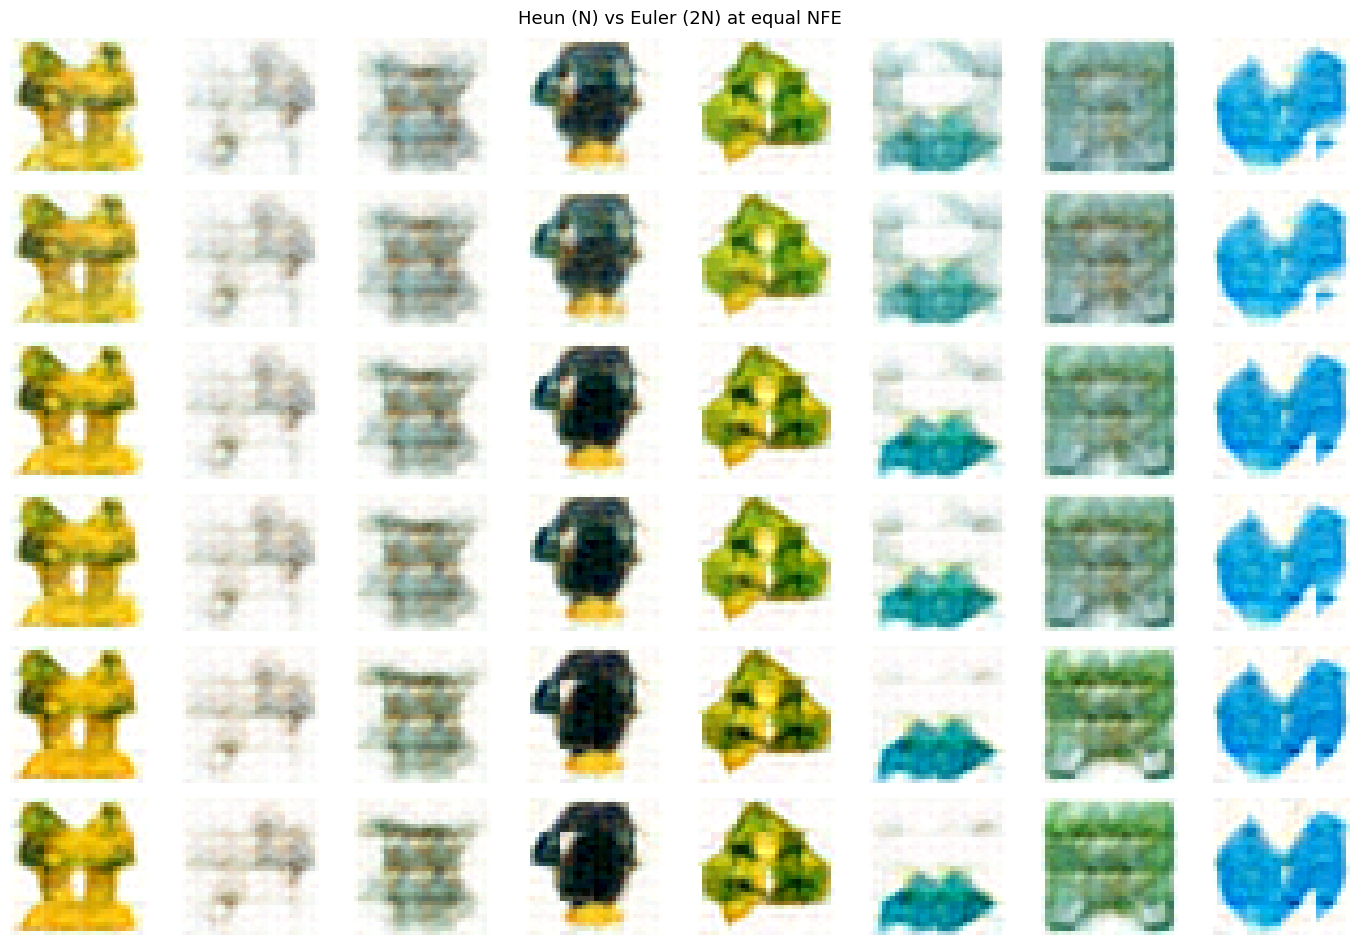

In [8]:
Ns = [5, 10, 25]
torch.manual_seed(7)
z0 = torch.randn(8, 3, 32, 32, device=device)
rows = []
labels = []
for Nh in Ns:
    rows.append(sample_heun(model, 8, Nh, device, z0=z0.clone()))
    labels.append(f'Heun N={Nh} ({2*Nh} NFE)')
    rows.append(sample_euler(model, 8, 2 * Nh, device, z0=z0.clone()))
    labels.append(f'Euler N={2*Nh} ({2*Nh} NFE)')

fig, axes = plt.subplots(len(rows), 8, figsize=(14, 1.6 * len(rows)))
def to_img(tn):
    return ((tn.cpu().permute(1, 2, 0).numpy() + 1) / 2).clip(0, 1)
for r, batch in enumerate(rows):
    for c in range(8):
        axes[r, c].imshow(to_img(batch[c])); axes[r, c].axis('off')
    axes[r, 0].set_ylabel(labels[r], fontsize=8, rotation=0, ha='right', va='center')
fig.suptitle('Heun (N) vs Euler (2N) at equal NFE', fontsize=13)
plt.tight_layout(); plt.show()

## A simple quality proxy
Reference: a high-step Euler run (T=200) as a stand-in for the 'true' ODE solution. We measure mean per-pixel L2 distance of each cheap sampler to this reference, using the same initial noise.

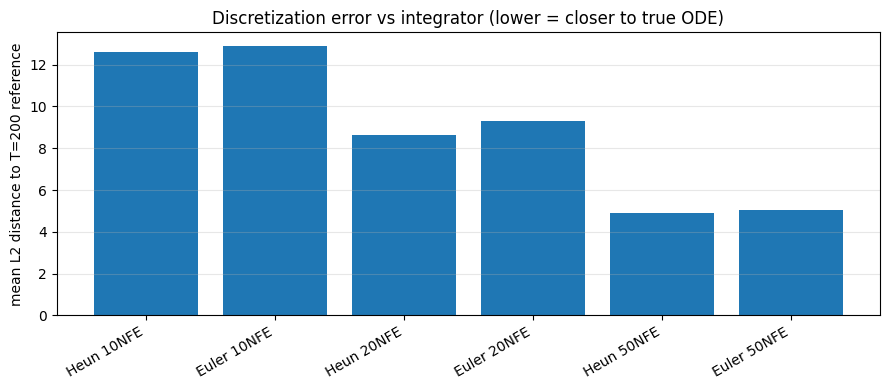

Heun 10NFE        12.593
Euler 10NFE       12.904
Heun 20NFE        8.658
Euler 20NFE       9.299
Heun 50NFE        4.894
Euler 50NFE       5.028


In [9]:
torch.manual_seed(11)
z0 = torch.randn(32, 3, 32, 32, device=device)
ref = sample_euler(model, 32, 200, device, z0=z0.clone())

def dist_to_ref(batch):
    return (batch - ref).flatten(1).norm(dim=1).mean().item()

results = {}
for Nh in Ns:
    results[f'Heun {2*Nh}NFE'] = dist_to_ref(sample_heun(model, 32, Nh, device, z0=z0.clone()))
    results[f'Euler {2*Nh}NFE'] = dist_to_ref(sample_euler(model, 32, 2 * Nh, device, z0=z0.clone()))

plt.figure(figsize=(9, 4))
plt.bar(range(len(results)), list(results.values()))
plt.xticks(range(len(results)), list(results.keys()), rotation=30, ha='right')
plt.ylabel('mean L2 distance to T=200 reference')
plt.title('Discretization error vs integrator (lower = closer to true ODE)')
plt.grid(True, axis='y', alpha=0.3); plt.tight_layout(); plt.show()
for k, v in results.items():
    print(f'{k:16s}  {v:.3f}')

## Discussion

- At matched NFE, Heun's 2nd-order corrector should track the high-step reference more closely than
  Euler, especially at small budgets (e.g. 10 NFE), where Euler's first-order error is most visible.
- Flow matching is famously forgiving with few steps because the trajectories are nearly straight, so the
  gap narrows as NFE grows.
- Connect to Karras et al. (2022): higher-order solvers buy quality per NFE, but with diminishing returns
  once discretization error drops below model error.

**For the writeup:** show the side-by-side grids and the distance-to-reference bar chart, and state at
which NFE Heun's advantage is largest.